# Scale-invariant transfer — test on all cities

Applies the **scale-invariant** Barcelona models (trained in `01_BCN_train_scale_invariant.ipynb` on the
10 percentile-ranked distance + centrality features) to every deployment city, and compares against the
**original full-18-feature raw model** (the pickles in `notebooks/_elena/models/` used by the deployment
test notebooks). Same evaluation, both tasks.

**No geospatial recomputation:** each city's raw distance/centrality columns already exist in its dataset
CSV; here we only `read_csv`, percentile-rank within the city (`rank(pct=True)`), and predict. The error
maps reuse the existing `<XXX>_noise_streets.gpkg`.

## Libraries, models and the percentile transform

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)

FEATURES_10 = [
    'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary',
    'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street',
    'betweenness', 'closeness_global', 'closeness_400', 'straightness',
]
PCT_COLS = [f + '_pct' for f in FEATURES_10]

def add_pct(df):
    out = df.copy()
    for f in FEATURES_10:
        out[f + '_pct'] = out[f].rank(pct=True)
    return out

In [2]:
SI = '../models'
RAW = '../../notebooks/_elena/models'

def load(p):
    with open(p, 'rb') as f:
        return pickle.load(f)

# scale-invariant (10 percentile features)
scaler_si = load(f'{SI}/Sscaler_si.pkl')
si_feats = load(f'{SI}/feature_columns_si.pkl')
si_class = {'Logistic Regression': load(f'{SI}/logreg_class_si.pkl'),
            'XGBoost': load(f'{SI}/xgb_class_si.pkl'),
            'Random Forest': load(f'{SI}/rf_class_si.pkl')}
si_regre = {'Linear Regression': load(f'{SI}/linreg_regre_si.pkl'),
            'XGBoost': load(f'{SI}/xgb_regre_si.pkl'),
            'Random Forest': load(f'{SI}/rf_regre_si.pkl')}

# original full-18 raw models
raw_scaler_c = load(f'{RAW}/Sscaler.pkl')
raw_feats_c = load(f'{RAW}/feature_columns.pkl')
raw_class = {'Logistic Regression': load(f'{RAW}/logreg_class_model.pkl'),
             'XGBoost': load(f'{RAW}/xgb_class_model.pkl'),
             'Random Forest': load(f'{RAW}/rf_class_model.pkl')}
raw_scaler_r = load(f'{RAW}/Sscaler_regre.pkl')
raw_feats_r = load(f'{RAW}/feature_columns_regre.pkl')
raw_regre = {'Linear Regression': load(f'{RAW}/linreg_regre_model.pkl'),
             'XGBoost': load(f'{RAW}/xgb_regre_model.pkl'),
             'Random Forest': load(f'{RAW}/rf_regre_model.pkl')}

print('raw full-18 features:', len(raw_feats_c), '| scale-invariant features:', len(si_feats))

raw full-18 features: 18 | scale-invariant features: 10


## City configuration

In [3]:
cities = [
    ('Viladecans', 'vil', 'VIL'),
    ('Milan',      'mil', 'MIL'),
    ('Berlin',     'ber', 'BER'),
    ('Lyon',       'lyo', 'LYO'),
    ('Zaragoza',   'zgz', 'ZGZ'),
]
RESULTS = '../results'
os.makedirs(RESULTS, exist_ok=True)

## Evaluate raw-18 vs scale-invariant-10 on every city (both tasks)

In [4]:
class_rows, regre_rows = [], []

for city, xxx, XXX in cities:
    cpath = f'../../deployment/{city}/notebooks/data/{xxx}_noise_class_ml_dataset.csv'
    rpath = f'../../deployment/{city}/notebooks/data/{xxx}_noise_regre_ml_dataset.csv'
    dfc = add_pct(pd.read_csv(cpath))
    dfr = add_pct(pd.read_csv(rpath))

    # design matrices
    Xc_raw = raw_scaler_c.transform(dfc[raw_feats_c]); Xc_si = scaler_si.transform(dfc[si_feats])
    Xr_raw = raw_scaler_r.transform(dfr[raw_feats_r]); Xr_si = scaler_si.transform(dfr[si_feats])
    yc = dfc['noise_day'].to_numpy()
    yr = dfr['noise_day'].to_numpy(dtype=float)

    # classification
    cls_pred = {'road_id': dfc['road_id'].values, 'noise_day_true': yc}
    for m in ['Logistic Regression', 'XGBoost', 'Random Forest']:
        for variant, X, model in [('raw-18', Xc_raw, raw_class[m]), ('SI-10', Xc_si, si_class[m])]:
            yp = model.predict(X)
            class_rows.append({'city': city, 'model': m, 'variant': variant,
                               'accuracy': accuracy_score(yc, yp),
                               'macro_f1': f1_score(yc, yp, average='macro'),
                               'within_1': np.mean(np.abs(yp - yc) <= 1),
                               'signed_err': np.mean(yp - yc)})
            if variant == 'SI-10':
                cls_pred[f'pred_{m.split()[0].lower()}_si'] = yp
    pd.DataFrame(cls_pred).to_csv(f'{RESULTS}/{xxx.lower()}_si_predictions_class.csv', index=False)

    # regression
    reg_pred = {'road_id': dfr['road_id'].values, 'db_true': yr}
    for m in ['Linear Regression', 'XGBoost', 'Random Forest']:
        for variant, X, model in [('raw-18', Xr_raw, raw_regre[m]), ('SI-10', Xr_si, si_regre[m])]:
            yp = np.asarray(model.predict(X), dtype=float)
            regre_rows.append({'city': city, 'model': m, 'variant': variant,
                               'r2': r2_score(yr, yp),
                               'mae': mean_absolute_error(yr, yp),
                               'rmse': np.sqrt(mean_squared_error(yr, yp)),
                               'signed_err': np.mean(yp - yr)})
            if variant == 'SI-10':
                reg_pred[f'pred_{m.split()[0].lower()}_si'] = yp.round(2)
    reg_pred['db_diff_rf_si'] = (reg_pred['pred_random_si'] - yr).round(2)
    pd.DataFrame(reg_pred).to_csv(f'{RESULTS}/{xxx.lower()}_si_predictions_regre.csv', index=False)
    print('done:', city)

class_cmp = pd.DataFrame(class_rows)
regre_cmp = pd.DataFrame(regre_rows)
class_cmp.to_csv(f'{RESULTS}/si_transfer_comparison_class.csv', index=False)
regre_cmp.to_csv(f'{RESULTS}/si_transfer_comparison_regre.csv', index=False)
print('saved comparison CSVs')

done: Viladecans


done: Milan


done: Berlin


done: Lyon


done: Zaragoza
saved comparison CSVs


### Classification — raw-18 vs scale-invariant-10 (accuracy)

In [5]:
acc = class_cmp.pivot_table(index='city', columns=['model', 'variant'], values='accuracy')
acc = acc.reindex([c[0] for c in cities]).round(3)
acc

model      Logistic Regression        Random Forest        XGBoost       
variant                  SI-10 raw-18         SI-10 raw-18   SI-10 raw-18
city                                                                     
Viladecans               0.490  0.558         0.469  0.469   0.468  0.524
Milan                    0.753  0.650         0.734  0.690   0.684  0.611
Berlin                   0.222  0.265         0.222  0.301   0.223  0.282
Lyon                     0.506  0.534         0.490  0.533   0.472  0.512
Zaragoza                 0.419  0.205         0.415  0.307   0.447  0.306

### Regression — raw-18 vs scale-invariant-10 (R²)

In [6]:
r2 = regre_cmp.pivot_table(index='city', columns=['model', 'variant'], values='r2')
r2 = r2.reindex([c[0] for c in cities]).round(3)
r2

model      Linear Regression        Random Forest        XGBoost       
variant                SI-10 raw-18         SI-10 raw-18   SI-10 raw-18
city                                                                   
Viladecans             0.492  0.058         0.290 -0.521   0.338 -1.813
Milan                 -2.599 -3.123        -3.129 -3.834  -3.467 -3.312
Berlin                -0.494 -0.368        -0.468  0.111  -0.590  0.166
Lyon                  -0.551 -0.009        -0.719 -0.560  -0.743 -0.877
Zaragoza               0.122 -1.509         0.017 -0.557   0.033 -0.555

## Headline figure — did scale-invariance fix transfer?

Random Forest (the strongest model). Left: classification accuracy (higher = better). Right: regression
R² (higher = better; raw transfer is often strongly negative). Paired bars: raw-18 vs scale-invariant-10.

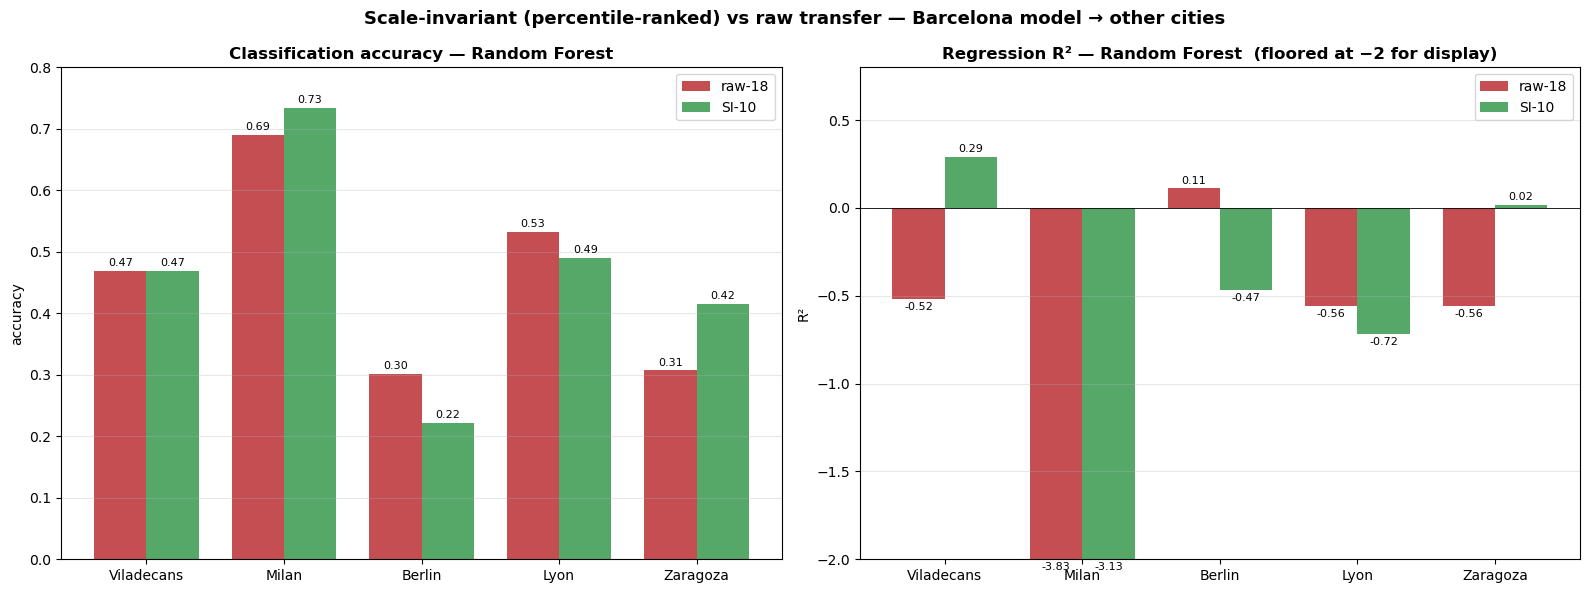

In [7]:
colors = {'raw-18': '#c44e52', 'SI-10': '#55a868'}
city_names = [c[0] for c in cities]
x = np.arange(len(city_names)); w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# classification accuracy (RF)
sub = class_cmp[class_cmp.model == 'Random Forest']
for j, variant in enumerate(['raw-18', 'SI-10']):
    vals = [sub[(sub.city == c) & (sub.variant == variant)]['accuracy'].values[0] for c in city_names]
    b = axes[0].bar(x + (j - 0.5) * w, vals, w, label=variant, color=colors[variant])
    axes[0].bar_label(b, fmt='%.2f', fontsize=8, padding=2)
axes[0].set_xticks(x); axes[0].set_xticklabels(city_names)
axes[0].set_title('Classification accuracy — Random Forest', fontweight='bold')
axes[0].set_ylabel('accuracy'); axes[0].set_ylim(0, 0.8)
axes[0].grid(axis='y', alpha=0.3); axes[0].legend()

# regression R² (RF), floored display with true labels
sub = regre_cmp[regre_cmp.model == 'Random Forest']
floor = -2.0
for j, variant in enumerate(['raw-18', 'SI-10']):
    true = [sub[(sub.city == c) & (sub.variant == variant)]['r2'].values[0] for c in city_names]
    disp = [max(v, floor) for v in true]
    b = axes[1].bar(x + (j - 0.5) * w, disp, w, label=variant, color=colors[variant])
    axes[1].bar_label(b, labels=[f'{v:.2f}' for v in true], fontsize=8, padding=2)
axes[1].set_xticks(x); axes[1].set_xticklabels(city_names)
axes[1].set_title('Regression R² — Random Forest  (floored at −2 for display)', fontweight='bold')
axes[1].set_ylabel('R²'); axes[1].set_ylim(floor, 0.8)
axes[1].axhline(0, color='k', lw=0.6); axes[1].grid(axis='y', alpha=0.3); axes[1].legend()

fig.suptitle('Scale-invariant (percentile-ranked) vs raw transfer — Barcelona model → other cities',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS}/fig_si_vs_raw_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-city error maps — scale-invariant regression (Random Forest)

`db_diff = predicted − real` dB for the scale-invariant RF model. Saved to HTML per city.

In [8]:
for city, xxx, XXX in cities:
    preds = pd.read_csv(f'{RESULTS}/{xxx.lower()}_si_predictions_regre.csv')
    gpkg = f'../../deployment/{city}/layers/{XXX}_noise_streets.gpkg'
    roads = gpd.read_file(gpkg)
    merged = roads.merge(preds, left_on='segment_id', right_on='road_id', how='left')
    m = merged.to_crs(epsg=4326).explore(
        column='db_diff_rf_si', cmap='RdBu_r', vmin=-15, vmax=15,
        tiles='CartoDB positron',
        tooltip=['road_id', 'db_diff_rf_si', 'pred_random_si', 'db_true', 'highway'],
        legend=True)
    out = f'{RESULTS}/{xxx.lower()}_si_map_db_diff_rf.html'
    m.save(out)
    print('saved', out)

C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


saved ../results/vil_si_map_db_diff_rf.html


saved ../results/mil_si_map_db_diff_rf.html


saved ../results/ber_si_map_db_diff_rf.html


saved ../results/lyo_si_map_db_diff_rf.html


saved ../results/zgz_si_map_db_diff_rf.html
